In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df = pd.read_csv('./dataset/penguins_size.csv')
df[:5]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [43]:
numerik_df = df[df.describe().columns]
kategori_df = df.drop(columns=numerik_df)

display(numerik_df)
display(kategori_df)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


,species,island,sex
0,Adelie,Torgersen,MALE
1,Adelie,Torgersen,FEMALE
2,Adelie,Torgersen,FEMALE
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,FEMALE
...,...,...,...
339,Gentoo,Biscoe,NaN
340,Gentoo,Biscoe,FEMALE
341,Gentoo,Biscoe,MALE
342,Gentoo,Biscoe,FEMALE


In [176]:
def table_diagnose(df):
    new_df = df.copy(deep=True)
    _1 = pd.concat([new_df.isnull().sum(), new_df.nunique(), new_df.dtypes], axis=1, keys=['n null', 'n unique', 'types']).reset_index()

    _2 = new_df.nunique().reset_index()
    _3 = _2.loc[_2[0] < 5, 'index'].apply(lambda x: new_df[x].unique())

    result = pd.merge(_1, _3, left_index=True, right_index=True, how='outer')
    result.rename(columns={'index_x': 'columns', 'index_y':'unique vals'}, inplace=True)
    return result

table_diagnose(df)

,columns,n null,n unique,types,unique vals
0,species,0,3,object,"[Adelie, Chinstrap, Gentoo]"
1,island,0,3,object,"[Torgersen, Biscoe, Dream]"
2,culmen_length_mm,2,164,float64,NaN
3,culmen_depth_mm,2,80,float64,NaN
4,flipper_length_mm,2,55,float64,NaN
5,body_mass_g,2,94,float64,NaN
6,sex,10,3,object,"[MALE, FEMALE, nan, .]"


In [4]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer()

numeric_df = get_data_types(df, 'numeric').isnull().sum()
target_cols = numeric_df[numeric_df > 0].index

df[target_cols] = imp.fit_transform(df[target_cols])

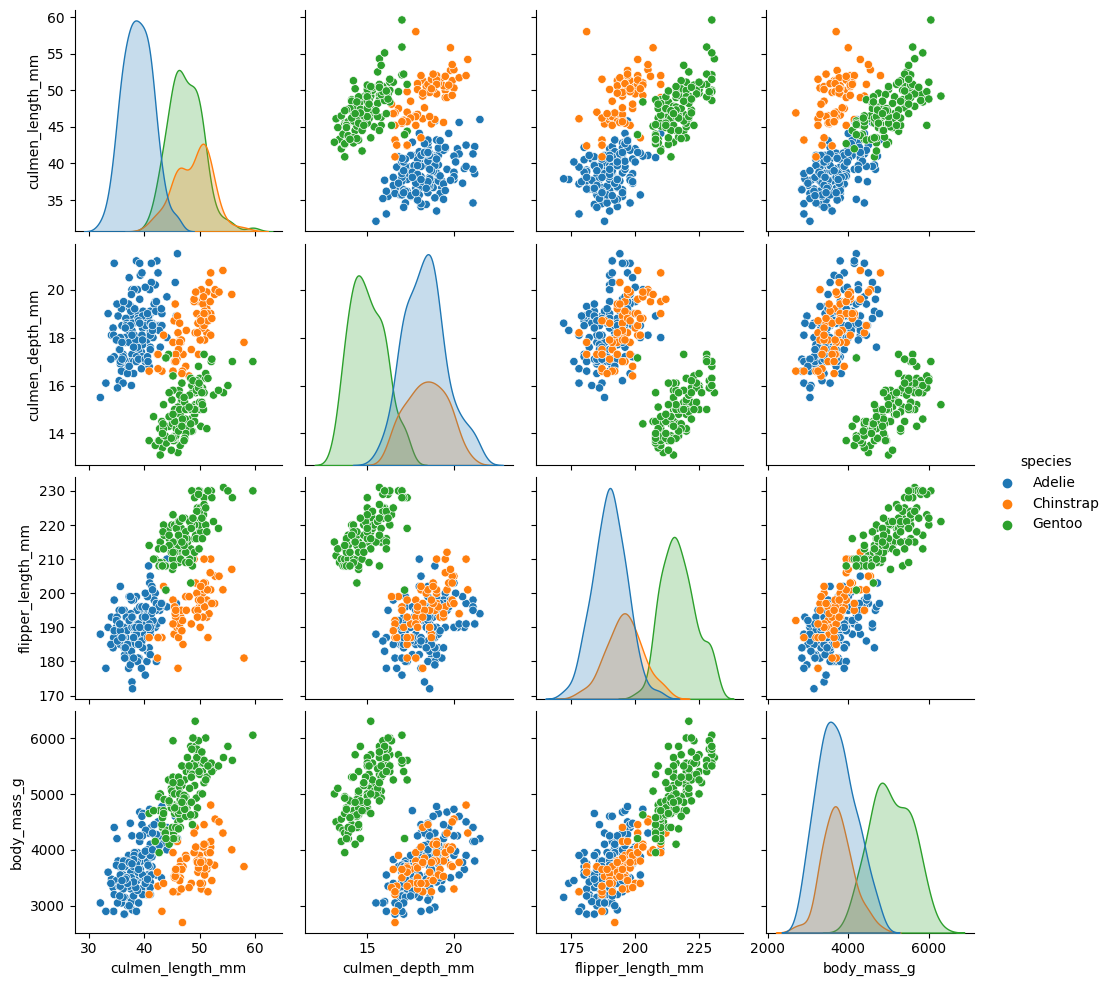

In [6]:
sns.pairplot(df, hue='species')
plt.show()

In [7]:
df.loc[~df['sex'].isin(['FEMALE', 'MALE']), ['species', 'sex']]

,species,sex
3,Adelie,NaN
8,Adelie,NaN
9,Adelie,NaN
10,Adelie,NaN
11,Adelie,NaN
47,Adelie,NaN
246,Gentoo,NaN
286,Gentoo,NaN
324,Gentoo,NaN
336,Gentoo,.


In [8]:
df['sex'] = df['sex'].replace({np.nan:df['sex'].mode()[0], '.':df['sex'].mode()[0]})

In [9]:
diagnose_data(df)

shape:
(344, 7)

columns:
['body_mass_g', 'culmen_depth_mm', 'culmen_length_mm', 'flipper_length_mm', 'island', 'sex', 'species']

n dtypes:
float64    4
object     3
dtype: int64

n uniques:
species: 3
island: 3
culmen_length_mm: 165
culmen_depth_mm: 81
flipper_length_mm: 56
body_mass_g: 95
sex: 2

unique values:
species: ['Adelie' 'Chinstrap' 'Gentoo']
island: ['Torgersen' 'Biscoe' 'Dream']
culmen_length_mm: [39.1        39.5        40.3        43.92192982 36.7        39.3
 38.9        39.2        34.1        42.         37.8        41.1
 38.6        34.6        36.6        38.7        42.5        34.4
 46.         37.7        35.9        38.2        38.8        35.3
 40.6        40.5        37.9        37.2        40.9        36.4
 42.2        37.6        39.8        36.5        40.8        36.
 44.1        37.         39.6        37.5        42.3        40.1
 35.         34.5        41.4        39.         35.7        41.3
 41.6        35.5        41.8        33.5        39.7      

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,MALE
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,FEMALE
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,FEMALE
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,MALE
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,FEMALE


In [10]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
df['sex'] = lb.fit_transform(df[['sex']])

df = pd.get_dummies(data=df, columns=['island'])

In [11]:
diagnose_data(df)

shape:
(344, 9)

columns:
['body_mass_g', 'culmen_depth_mm', 'culmen_length_mm', 'flipper_length_mm', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex', 'species']

n dtypes:
float64    4
uint8      3
object     1
int64      1
dtype: int64

n uniques:
species: 3
culmen_length_mm: 165
culmen_depth_mm: 81
flipper_length_mm: 56
body_mass_g: 95
sex: 2
island_Biscoe: 2
island_Dream: 2
island_Torgersen: 2

unique values:
species: ['Adelie' 'Chinstrap' 'Gentoo']
culmen_length_mm: [39.1        39.5        40.3        43.92192982 36.7        39.3
 38.9        39.2        34.1        42.         37.8        41.1
 38.6        34.6        36.6        38.7        42.5        34.4
 46.         37.7        35.9        38.2        38.8        35.3
 40.6        40.5        37.9        37.2        40.9        36.4
 42.2        37.6        39.8        36.5        40.8        36.
 44.1        37.         39.6        37.5        42.3        40.1
 35.         34.5        41.4        39.         35.

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.10000,18.70000,181.000000,3750.000000,1,0,0,1
1,Adelie,39.50000,17.40000,186.000000,3800.000000,0,0,0,1
2,Adelie,40.30000,18.00000,195.000000,3250.000000,0,0,0,1
3,Adelie,43.92193,17.15117,200.915205,4201.754386,1,0,0,1
4,Adelie,36.70000,19.30000,193.000000,3450.000000,0,0,0,1


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

diagnose_data(df)

shape:
(344, 9)

columns:
['body_mass_g', 'culmen_depth_mm', 'culmen_length_mm', 'flipper_length_mm', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex', 'species']

n dtypes:
float64    4
uint8      3
int64      2
dtype: int64

n uniques:
species: 3
culmen_length_mm: 165
culmen_depth_mm: 81
flipper_length_mm: 56
body_mass_g: 95
sex: 2
island_Biscoe: 2
island_Dream: 2
island_Torgersen: 2

unique values:
species: [0 1 2]
culmen_length_mm: [39.1        39.5        40.3        43.92192982 36.7        39.3
 38.9        39.2        34.1        42.         37.8        41.1
 38.6        34.6        36.6        38.7        42.5        34.4
 46.         37.7        35.9        38.2        38.8        35.3
 40.6        40.5        37.9        37.2        40.9        36.4
 42.2        37.6        39.8        36.5        40.8        36.
 44.1        37.         39.6        37.5        42.3        40.1
 35.         34.5        41.4        39.         35.7        41.3
 41.6        35.5      

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,0,39.10000,18.70000,181.000000,3750.000000,1,0,0,1
1,0,39.50000,17.40000,186.000000,3800.000000,0,0,0,1
2,0,40.30000,18.00000,195.000000,3250.000000,0,0,0,1
3,0,43.92193,17.15117,200.915205,4201.754386,1,0,0,1
4,0,36.70000,19.30000,193.000000,3450.000000,0,0,0,1


In [13]:
X = df.drop(columns='species', axis='columns')
y = df['species']

In [14]:
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,39.10000,18.70000,181.000000,3750.000000,1,0,0,1
1,39.50000,17.40000,186.000000,3800.000000,0,0,0,1
2,40.30000,18.00000,195.000000,3250.000000,0,0,0,1
3,43.92193,17.15117,200.915205,4201.754386,1,0,0,1
4,36.70000,19.30000,193.000000,3450.000000,0,0,0,1


In [15]:
y.unique()

array([0, 1, 2])

In [16]:
from sklearn.preprocessing import MinMaxScaler

cols_scale = [col for col in X.columns if len(X[col].unique()) > 2]

scaler = MinMaxScaler()
X[cols_scale] = scaler.fit_transform(X[cols_scale])

In [17]:
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,0.254545,0.666667,0.152542,0.291667,1,0,0,1
1,0.269091,0.511905,0.237288,0.305556,0,0,0,1
2,0.298182,0.583333,0.389831,0.152778,0,0,0,1
3,0.429888,0.482282,0.490088,0.417154,1,0,0,1
4,0.167273,0.738095,0.355932,0.208333,0,0,0,1


In [18]:
from sklearn.feature_selection import f_classif
f, p = f_classif(X[cols_scale], y)

f, p

(array([405.48163828, 354.41046638, 579.15971127, 338.57291008]),
 array([7.23326619e-091, 5.42594307e-084, 2.21139411e-110, 1.00697705e-081]))

In [19]:
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X[cols_scale], y)

mi

array([0.56069144, 0.55633012, 0.60415895, 0.48369631])

In [20]:
feature_score = pd.DataFrame(
    {
        'Feature': X[cols_scale].columns,
        'F': f,
        'MI': mi,
    }
).sort_values(
    'MI', ascending=False
)

feature_score.style.bar(
    subset=['F', 'MI'], color='grey'
)

,Feature,F,MI
2,flipper_length_mm,579.159711,0.604159
0,culmen_length_mm,405.481638,0.560691
1,culmen_depth_mm,354.410466,0.556330
3,body_mass_g,338.572910,0.483696


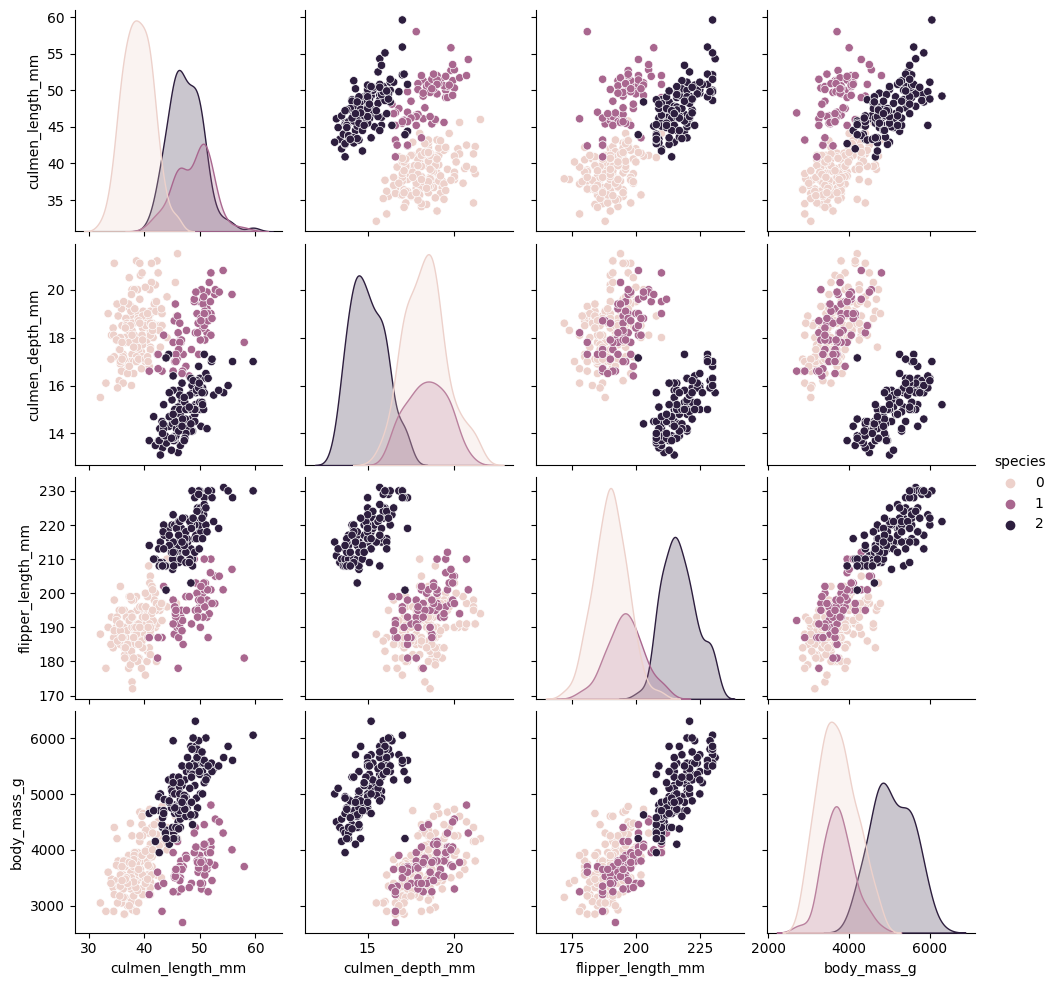

In [21]:
sns.pairplot(data=df[['species', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']], hue='species')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_validate

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.25,
    random_state=1
)

In [25]:
model_params=[
    {
        'model_name': 'DecisionTreeClassifier',
        'model': DecisionTreeClassifier()
    },
    {
        'model_name': 'RandomForestClassifier',
        'model': RandomForestClassifier()
    },
    {
        'model_name': 'LogisticRegression',
        'model': LogisticRegression()
    },
    {
        'model_name': 'SVM',
        'model': SVC()
    },
    {
        'model_name': 'KNeighborsClassifier',
        'model': KNeighborsClassifier()
    }
]

def tuning_models(X, y, model_params, model_name='model_name', model='model', max_splits=20, get_mean=False):
    rs = ShuffleSplit(n_splits=max_splits, test_size=.2, random_state=0)
    estimated_model = {}
    for idx in range(len(model_params)):
        cv_results = cross_validate(
            model_params[idx]['model'], X, y, cv=rs, scoring='accuracy'
        )
        estimated_model[model_params[idx]['model_name']]= cv_results['test_score']
    df_scoring = pd.DataFrame(estimated_model, index=[f'score {i}' for i in range(max_splits)])
    
    if get_mean:
        for col in df_scoring.columns:
            print(f'{col}: {df_scoring[col].mean()}')
    else:
        return df_scoring

In [26]:
tuning_models(X_train, y_train, model_params, 'model_name', 'model', 20)

,DecisionTreeClassifier,RandomForestClassifier,LogisticRegression,SVM,KNeighborsClassifier
score 0,0.980769,0.980769,0.980769,0.980769,0.961538
score 1,0.942308,0.980769,1.000000,1.000000,1.000000
score 2,0.942308,0.961538,0.961538,0.980769,0.980769
score 3,0.961538,0.980769,0.980769,1.000000,1.000000
score 4,1.000000,1.000000,1.000000,0.980769,0.980769
score 5,0.923077,0.961538,0.980769,1.000000,1.000000
score 6,1.000000,1.000000,1.000000,1.000000,1.000000
score 7,0.942308,1.000000,1.000000,1.000000,1.000000
score 8,1.000000,1.000000,1.000000,1.000000,1.000000
score 9,0.961538,0.980769,0.980769,0.961538,0.961538


In [27]:
tuning_models(X, y, model_params, 'model_name', 'model', 20, get_mean=True)

DecisionTreeClassifier: 0.9688405797101451
RandomForestClassifier: 0.98768115942029
LogisticRegression: 0.9898550724637681
SVM: 0.9905797101449275
KNeighborsClassifier: 0.9898550724637681


In [28]:
scores = []

clf = GridSearchCV(
    estimator=SVC(random_state=0),
    param_grid={   
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'C': [0.5, 1, 10, 100],
        'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001]
    },
    cv=20,
    n_jobs=4,
    return_train_score=False
)
clf.fit(X_train, y_train)
scores.append({
    'model': 'SVM',
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
})

In [29]:
cv_df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
cv_df

,model,best_score,best_params
0,SVM,0.996154,"{'C': 100, 'gamma': 0.1, 'kernel': 'sigmoid'}"


In [30]:
from sklearn.metrics import classification_report

model = SVC(C = 100, gamma= 0.1, kernel= 'sigmoid', random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        30

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



In [31]:
series_pred = pd.Series(le.inverse_transform(y_pred))

In [32]:
series_test = pd.Series(le.inverse_transform(y_test))

In [33]:
pd.concat([series_test, series_pred], axis='columns', keys=['test', 'predicted'])

,test,predicted
0,Gentoo,Gentoo
1,Gentoo,Gentoo
2,Gentoo,Gentoo
3,Adelie,Adelie
4,Gentoo,Gentoo
...,...,...
81,Gentoo,Gentoo
82,Adelie,Adelie
83,Adelie,Adelie
84,Gentoo,Gentoo
